<a href="https://colab.research.google.com/github/MaryumAkram16/Resume-Screener/blob/main/resume_screener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resume Screener - Full Pipeline

Part 1: EDA on the raw resume dataset.
Part 2: Stage 1 - category classifier (TF-IDF + Logistic Regression).
Part 3: Stage 2 - suitability scoring against a job description (Gradient Boosting,
trained on real resume-JD pairs plus synthetic negative examples).
Part 4: downloads everything - every chart and table produced along the way,
plus the trained models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, explained_variance_score
)

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 120)

## Load the resume data

Uploading `Resume.csv` to Colab first (either drag it into the file browser or mount drive).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Resume.csv')
df.shape

(2484, 4)

In [5]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Customer Service Manag...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsectio...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with background in Communic...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsectio...",HR
2,33176873,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years in Human Resources E...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsectio...",HR
3,27018550,"HR SPECIALIST Summary Dedicated, Driven, and Dynamic with over 20 years of customer service expert...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsectio...",HR
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Department Startup Three New Organization Star...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=""section firstsectio...",HR


In [6]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


,0
ID,0
Resume_str,0
Resume_html,0
Category,0


# Part 1 - EDA

## Category balance

This is what I'll actually be predicting, so want to see how skewed it is before picking a model / eval metric.

In [7]:
cat_counts = df['Category'].value_counts()
cat_counts

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


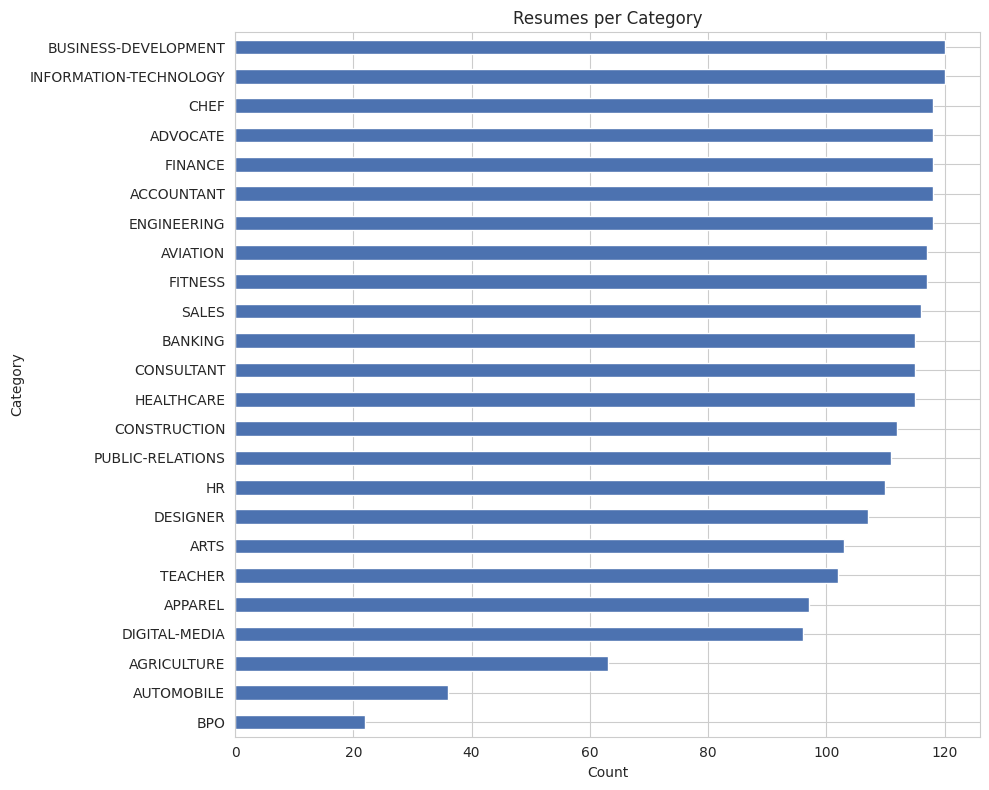

In [8]:
plt.figure(figsize=(10, 8))
cat_counts.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Resumes per Category')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('chart_resumes_per_category.png', dpi=150)
plt.show()

A few categories (BPO, Automobile, Agriculture) have way fewer samples than the rest.
Might need to merge these into a bigger bucket or just keep an eye on their recall later,
oversampling probably isn't worth it for this few examples.

## Duplicates and junk rows

Checking for exact duplicate resumes and anything basically empty.

In [9]:
dupes = df[df.duplicated('Resume_str', keep=False)]
print(f"Duplicate resume rows: {len(dupes)}")
dupes[['ID', 'Category']]

Duplicate resume rows: 4


,ID,Category
1490,19147603,FINANCE
1509,28398216,FINANCE
2444,16850314,AVIATION
2483,37473139,AVIATION


In [10]:
df['word_count'] = df['Resume_str'].apply(lambda x: len(str(x).split()))

# anything under ~10 words is basically empty, not a real resume
empty_rows = df[df['word_count'] < 10]
empty_rows[['ID', 'Category', 'word_count']]

,ID,Category,word_count
656,12632728,BUSINESS-DEVELOPMENT,0


In [11]:
# drop the junk before it messes with training later
df = df.drop_duplicates(subset='Resume_str')
df = df[df['word_count'] >= 10].reset_index(drop=True)
df.shape

(2481, 5)

## Resume length

Wondering if length itself might be predictive of category (longer resumes = more senior
roles maybe?), and also just want to know what I'm dealing with for tokenization limits later.

In [12]:
df['word_count'].describe()

,word_count
count,2481.000000
mean,811.770254
std,370.849927
min,113.000000
25%,651.000000
50%,757.000000
75%,933.000000
max,5190.000000


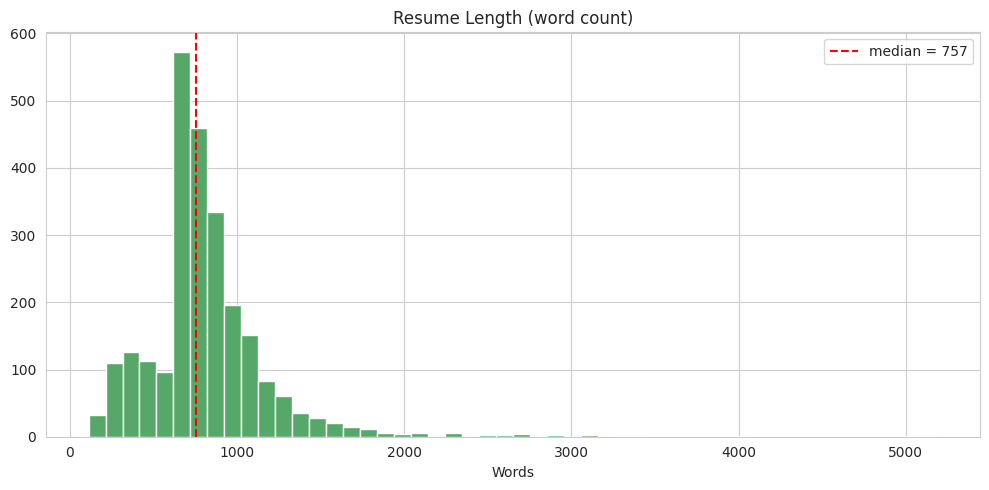

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=50, color='#55A868', edgecolor='white')
plt.axvline(df['word_count'].median(), color='red', linestyle='--',
            label=f"median = {df['word_count'].median():.0f}")
plt.title('Resume Length (word count)')
plt.xlabel('Words')
plt.legend()
plt.tight_layout()
plt.savefig('chart_resume_length.png', dpi=150)
plt.show()

In [14]:
avg_len_by_cat = df.groupby('Category')['word_count'].mean().sort_values(ascending=False)
avg_len_by_cat

,word_count
Category,
BPO,974.227273
INFORMATION-TECHNOLOGY,926.583333
PUBLIC-RELATIONS,889.315315
HEALTHCARE,881.773913
CONSULTANT,879.704348
AGRICULTURE,856.285714
HR,853.727273
CONSTRUCTION,852.714286
ADVOCATE,848.500000


## Text cleanup

The raw text has extra whitespace and a few leftover HTML tags from how it was scraped.
Cleaning this up properly before vectorizing / tokenizing.

In [15]:
has_tags = df['Resume_str'].str.contains(r'<[^>]+>', regex=True).sum()
print(f"Rows with leftover HTML tags: {has_tags}")

# peek at one raw sample to see what we're dealing with
print(repr(df['Resume_str'].iloc[0][:300]))

Rows with leftover HTML tags: 8
'         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit'


In [16]:
def clean_resume(text):
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)      # strip stray html tags
    text = re.sub(r'\s+', ' ', text)          # collapse whitespace/newlines
    text = text.strip()
    return text

df['Resume_clean'] = df['Resume_str'].apply(clean_resume)
df[['Resume_str', 'Resume_clean']].iloc[0]['Resume_clean'][:300]

'HR ADMINISTRATOR/MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer servi'

## Most common words per category

Just a sanity check that the categories actually look distinguishable from word usage
before throwing a model at it.

In [17]:
def top_words(category, n=15):
    text = df[df['Category'] == category]['Resume_clean']
    vec = CountVectorizer(stop_words='english', max_features=5000)
    matrix = vec.fit_transform(text)
    counts = matrix.sum(axis=0).A1
    words = vec.get_feature_names_out()
    top = sorted(zip(words, counts), key=lambda x: -x[1])[:n]
    return top

top_words_summary = {}
for cat in ['INFORMATION-TECHNOLOGY', 'CHEF', 'FINANCE']:
    top_words_summary[cat] = top_words(cat)
    print(cat)
    print(top_words_summary[cat])
    print()

INFORMATION-TECHNOLOGY
[('management', np.int64(898)), ('information', np.int64(860)), ('systems', np.int64(742)), ('technology', np.int64(742)), ('support', np.int64(673)), ('network', np.int64(669)), ('company', np.int64(651)), ('state', np.int64(638)), ('city', np.int64(616)), ('project', np.int64(565)), ('data', np.int64(558)), ('business', np.int64(554)), ('software', np.int64(541)), ('security', np.int64(432)), ('microsoft', np.int64(374))]

CHEF
[('food', np.int64(1348)), ('state', np.int64(805)), ('city', np.int64(761)), ('chef', np.int64(720)), ('company', np.int64(700)), ('kitchen', np.int64(587)), ('service', np.int64(478)), ('management', np.int64(470)), ('staff', np.int64(450)), ('customer', np.int64(366)), ('skills', np.int64(357)), ('culinary', np.int64(351)), ('quality', np.int64(335)), ('training', np.int64(317)), ('team', np.int64(313))]

FINANCE
[('financial', np.int64(1103)), ('management', np.int64(789)), ('company', np.int64(785)), ('finance', np.int64(762)), ('st

# Part 2 - Stage 1: Category Classifier

`df` already has the cleaned text from Part 1 (`Resume_clean`), so picking up straight
from there instead of re-loading anything.

Going with TF-IDF + Logistic Regression as the baseline - simple, fast, and gives me
probability scores I'll need later for the suitability scoring stage.

## Merging overlapping categories

First pass at this gave 66% accuracy on the raw 24 categories. Looked at the confusion
matrix and Consultant / Business-Development / Sales were constantly getting mixed up
with each other - makes sense, the language in those resumes genuinely overlaps.

Also dropping Automobile and BPO - only 7 and 4 samples in the test set, not enough
to learn a reliable pattern from, they were mostly just adding noise.

In [18]:
merge_map = {
    'CONSULTANT': 'BUSINESS',
    'BUSINESS-DEVELOPMENT': 'BUSINESS',
    'SALES': 'BUSINESS',
}
df['Category_merged'] = df['Category'].replace(merge_map)

counts = df['Category_merged'].value_counts()
drop_list = counts[counts < 40].index.tolist()
print("Dropping (too few samples):", drop_list)

df_model = df[~df['Category_merged'].isin(drop_list)].reset_index(drop=True)
print(f"Classes: {df_model['Category_merged'].nunique()} | Rows: {len(df_model)}")

Dropping (too few samples): ['AUTOMOBILE', 'BPO']
Classes: 20 | Rows: 2423


## Train/test split

Stratifying by the merged category so every class shows up in both splits instead
of randomly landing all in one.

In [19]:
X_cat = df_model['Resume_clean']
y_cat = df_model['Category_merged']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

print(f"Train: {len(X_train_cat)} | Test: {len(X_test_cat)}")

Train: 1938 | Test: 485


## TF-IDF vectorization

In [20]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train_cat)
X_test_tfidf = vectorizer.transform(X_test_cat)

X_train_tfidf.shape

(1938, 10000)

## Train the model

Using lbfgs since it handles multiclass properly. class_weight='balanced' so the
model pays more attention to the small classes instead of just optimizing for the
big ones.

In [21]:
clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)

clf.fit(X_train_tfidf, y_train_cat)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Evaluate

In [22]:
y_pred_cat = clf.predict(X_test_tfidf)
acc = accuracy_score(y_test_cat, y_pred_cat)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.680


In [23]:
classification_report_dict = classification_report(y_test_cat, y_pred_cat, output_dict=True)
classification_report_df = pd.DataFrame(classification_report_dict).transpose()
classification_report_df

,precision,recall,f1-score,support
ACCOUNTANT,0.724138,0.875000,0.792453,24.000000
ADVOCATE,0.500000,0.541667,0.520000,24.000000
AGRICULTURE,0.777778,0.538462,0.636364,13.000000
APPAREL,0.444444,0.421053,0.432432,19.000000
ARTS,0.529412,0.428571,0.473684,21.000000
AVIATION,0.736842,0.608696,0.666667,23.000000
BANKING,0.842105,0.695652,0.761905,23.000000
BUSINESS,0.660377,0.500000,0.569106,70.000000
CHEF,0.789474,0.625000,0.697674,24.000000
CONSTRUCTION,0.850000,0.772727,0.809524,22.000000


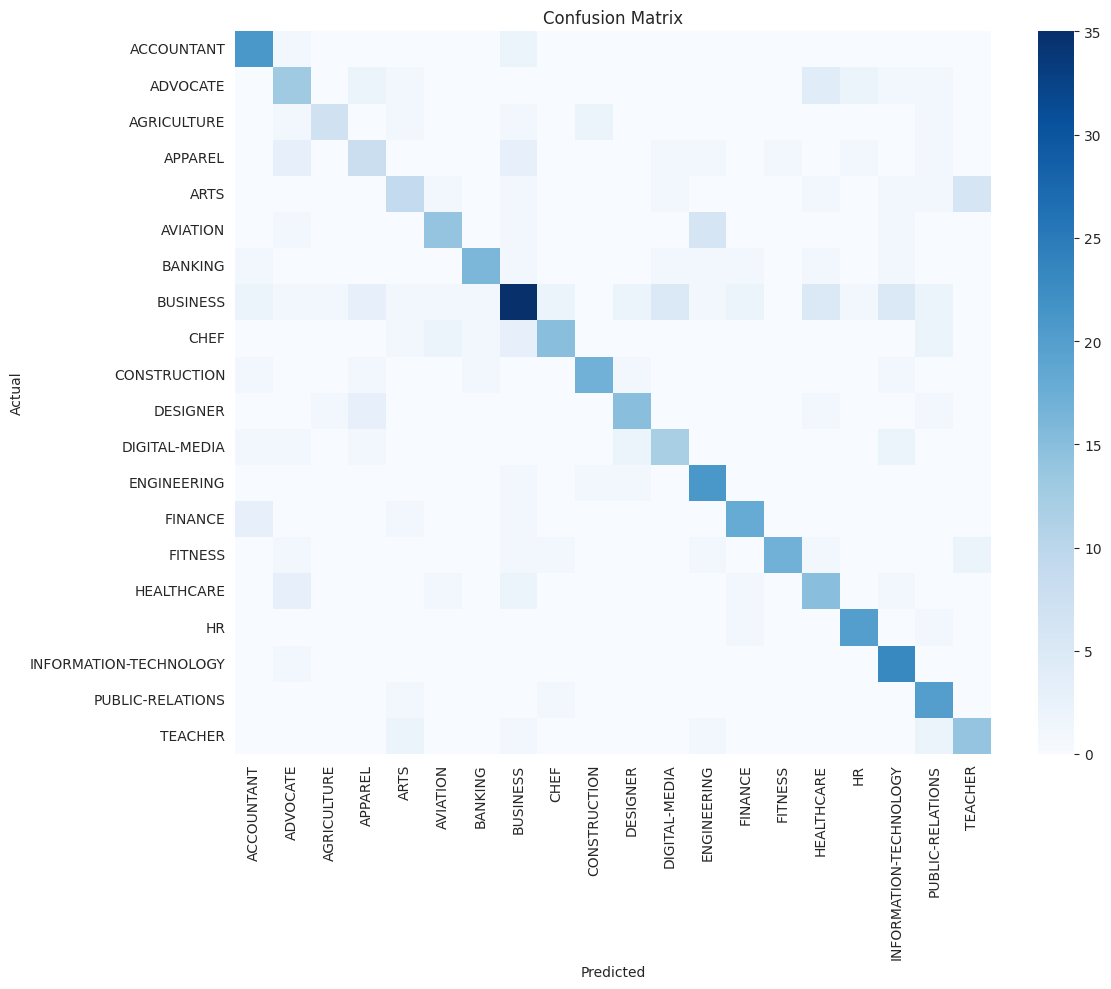

In [24]:
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=clf.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart_confusion_matrix.png', dpi=150)
plt.show()

## Where's it getting confused?

In [25]:
cm_df = pd.DataFrame(cm, index=clf.classes_, columns=clf.classes_)
mistakes = []
for actual in cm_df.index:
    for predicted in cm_df.columns:
        if actual != predicted and cm_df.loc[actual, predicted] > 0:
            mistakes.append((actual, predicted, cm_df.loc[actual, predicted]))

mistakes_df = pd.DataFrame(mistakes, columns=['actual', 'predicted', 'count'])
mistakes_df = mistakes_df.sort_values('count', ascending=False).reset_index(drop=True)
mistakes_df.head(15)

,actual,predicted,count
0,AVIATION,ENGINEERING,6
1,ARTS,TEACHER,6
2,BUSINESS,DIGITAL-MEDIA,5
3,BUSINESS,HEALTHCARE,5
4,BUSINESS,INFORMATION-TECHNOLOGY,5
5,ADVOCATE,HEALTHCARE,4
6,APPAREL,ADVOCATE,3
7,BUSINESS,APPAREL,3
8,APPAREL,BUSINESS,3
9,DESIGNER,APPAREL,3


## Try it on a couple of test resumes manually

In [26]:
def predict_category(text, top_n=3):
    vec = vectorizer.transform([text])
    probs = clf.predict_proba(vec)[0]
    top_idx = np.argsort(probs)[::-1][:top_n]
    return [(clf.classes_[i], round(probs[i], 3)) for i in top_idx]

sample = X_test_cat.iloc[0]
print(sample[:200], "...\n")
print("Actual:", y_test_cat.iloc[0])
print("Predicted:", predict_category(sample))

WELLNESS DIRECTOR Professional Summary Skills SKILLS Body composition evaluations Telehealth experience Group Instruction One-on-one coaching Health education Data management Supervision Planning and  ...

Actual: FITNESS
Predicted: [('FITNESS', np.float64(0.681)), ('HEALTHCARE', np.float64(0.045)), ('ADVOCATE', np.float64(0.03))]


# Part 3 - Stage 2: Suitability Scoring

Scoring how well a resume fits a specific job description, using the
job_resume_fit dataset (real resume-JD pairs with match scores) plus synthetic
negative examples so the model also learns what a bad match looks like.

In [27]:
!pip install datasets sentence-transformers --quiet

from datasets import load_dataset

ds = load_dataset("batuhanmtl/job_resume_fit")
df_jobs = ds['train'].to_pandas()
df_jobs.shape

README.md:   0%|          | 0.00/1.36k [00:00<?, ?B/s]

job_resume_fit.csv: reconstructing file:   0%|          |  0.00B / 30.5MB            

job_resume_fit.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2385 [00:00<?, ? examples/s]

(2385, 10)

In [28]:
def parse_skill_list(s):
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

df_jobs['resume_skills_parsed'] = df_jobs['resume_skill_list'].apply(parse_skill_list)
df_jobs['job_skills_parsed'] = df_jobs['job_required_skills'].apply(parse_skill_list)

## Generating negative examples

The dataset as-is only pairs resumes with jobs they were actually matched against,
so the model never sees a genuinely bad match. Pairing some resumes with a job
from a different category and giving those a low synthetic score (0-15) fixes
that - this is a heuristic assumption, not real labeled data, worth being
upfront about in the writeup.

In [29]:
def make_negative_pairs(df, n_samples, seed=42):
    rng = np.random.RandomState(seed)
    neg_rows = []
    for _ in range(n_samples):
        resume_row = df.sample(1, random_state=rng.randint(0, 1_000_000)).iloc[0]
        other_cats = df[df['category'] != resume_row['category']]
        if len(other_cats) == 0:
            continue
        job_row = other_cats.sample(1, random_state=rng.randint(0, 1_000_000)).iloc[0]
        neg_rows.append({
            'ID': f"neg_{resume_row['ID']}_{job_row['ID']}",
            'resume_text': resume_row['resume_text'],
            'job_text': job_row['job_text'],
            'category': job_row['category'],
            'job_required_skills': job_row['job_required_skills'],
            'resume_skill_list': resume_row['resume_skill_list'],
            'resume_skills_parsed': resume_row['resume_skills_parsed'],
            'job_skills_parsed': job_row['job_skills_parsed'],
            'ai_match_score': rng.uniform(0, 15),
            'skill_string_match_score': rng.uniform(0, 5),
            'fuzzy_match_score': rng.uniform(10, 30),
        })
    return pd.DataFrame(neg_rows)

neg_df = make_negative_pairs(df_jobs, n_samples=len(df_jobs) // 3)
print(f"Negative pairs created: {len(neg_df)}")

df_full = pd.concat([df_jobs, neg_df], ignore_index=True, sort=False)
print(f"Combined dataset: {df_full.shape}")

Negative pairs created: 795
Combined dataset: (3180, 12)


## Feature engineering

In [30]:
def skill_overlap_ratio(row):
    r = set(s.lower().strip() for s in row['resume_skills_parsed'])
    j = set(s.lower().strip() for s in row['job_skills_parsed'])
    if not j:
        return 0.0
    return len(r & j) / len(j)

def skill_overlap_count(row):
    r = set(s.lower().strip() for s in row['resume_skills_parsed'])
    j = set(s.lower().strip() for s in row['job_skills_parsed'])
    return len(r & j)

df_full['skill_overlap_ratio'] = df_full.apply(skill_overlap_ratio, axis=1)
df_full['skill_overlap_count'] = df_full.apply(skill_overlap_count, axis=1)

In [31]:
df_full['resume_word_count'] = df_full['resume_text'].apply(lambda x: len(str(x).split()))
df_full['job_word_count'] = df_full['job_text'].apply(lambda x: len(str(x).split()))
df_full['length_ratio'] = df_full.apply(
    lambda r: min(r['resume_word_count'], r['job_word_count']) / max(r['resume_word_count'], r['job_word_count'], 1),
    axis=1
)

In [32]:
vectorizer_s2 = TfidfVectorizer(stop_words='english', max_features=8000)
vectorizer_s2.fit(pd.concat([df_full['resume_text'], df_full['job_text']]))

resume_vecs = vectorizer_s2.transform(df_full['resume_text'])
job_vecs = vectorizer_s2.transform(df_full['job_text'])
df_full['text_similarity'] = [
    cosine_similarity(resume_vecs[i], job_vecs[i])[0][0]
    for i in range(len(df_full))
]

In [33]:
df_full['resume_skills_text'] = df_full['resume_skills_parsed'].apply(lambda l: ' '.join(l))
df_full['job_skills_text'] = df_full['job_skills_parsed'].apply(lambda l: ' '.join(l))

skill_vectorizer = TfidfVectorizer(stop_words='english', max_features=4000)
skill_vectorizer.fit(pd.concat([df_full['resume_skills_text'], df_full['job_skills_text']]))

rsv = skill_vectorizer.transform(df_full['resume_skills_text'])
jsv = skill_vectorizer.transform(df_full['job_skills_text'])
df_full['skill_text_similarity'] = [
    cosine_similarity(rsv[i], jsv[i])[0][0]
    for i in range(len(df_full))
]

## Embedding-based similarity

In [34]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

resume_embeddings = embed_model.encode(df_full['resume_text'].tolist(), show_progress_bar=True)
job_embeddings = embed_model.encode(df_full['job_text'].tolist(), show_progress_bar=True)

df_full['embedding_similarity'] = [
    cosine_similarity([resume_embeddings[i]], [job_embeddings[i]])[0][0]
    for i in range(len(df_full))
]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

## Train/test split

In [35]:
feature_cols = [
    'skill_overlap_ratio', 'skill_overlap_count', 'length_ratio',
    'text_similarity', 'skill_text_similarity', 'embedding_similarity',
    'skill_string_match_score', 'fuzzy_match_score'
]

X_suit = df_full[feature_cols]
y_suit = df_full['ai_match_score']

X_train_suit, X_test_suit, y_train_suit, y_test_suit = train_test_split(
    X_suit, y_suit, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train_suit)} | Test: {len(X_test_suit)}")

Train: 2544 | Test: 636


## Comparing model types

Tried Random Forest, Gradient Boosting, and a tuned Random Forest - Gradient
Boosting came out ahead on every metric (MAE 8.69 vs 8.98-9.04), so that's
the final model.

In [36]:
def evaluate(name, y_true, y_pred):
    row = {
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'Median_AE': median_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'Explained_Variance': explained_variance_score(y_true, y_pred),
    }
    print(f"--- {name} ---")
    for k, v in row.items():
        if k != 'model':
            print(f"{k}: {v:.3f}")
    print()
    return row

In [37]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_suit, y_train_suit)
rf_pred = rf_model.predict(X_test_suit)
rf_row = evaluate("Random Forest", y_test_suit, rf_pred)

--- Random Forest ---
MAE: 9.036
RMSE: 11.993
Median_AE: 6.885
R2: 0.799
Explained_Variance: 0.799



In [38]:
gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb_model.fit(X_train_suit, y_train_suit)
gb_pred = gb_model.predict(X_test_suit)
gb_row = evaluate("Gradient Boosting", y_test_suit, gb_pred)

--- Gradient Boosting ---
MAE: 8.694
RMSE: 11.541
Median_AE: 6.563
R2: 0.814
Explained_Variance: 0.814



In [39]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 10, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_search.fit(X_train_suit, y_train_suit)

print("Best params:", grid_search.best_params_)
tuned_pred = grid_search.best_estimator_.predict(X_test_suit)
tuned_row = evaluate("Tuned Random Forest", y_test_suit, tuned_pred)

Best params: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
--- Tuned Random Forest ---
MAE: 8.982
RMSE: 11.945
Median_AE: 6.827
R2: 0.801
Explained_Variance: 0.801



In [40]:
model_comparison_df = pd.DataFrame([rf_row, gb_row, tuned_row]).set_index('model')
model_comparison_df = model_comparison_df.sort_values('MAE')
model_comparison_df

,MAE,RMSE,Median_AE,R2,Explained_Variance
model,,,,,
Gradient Boosting,8.694097,11.540711,6.562911,0.813909,0.814141
Tuned Random Forest,8.982333,11.944640,6.827439,0.800654,0.800997
Random Forest,9.036409,11.992760,6.884910,0.799045,0.799373


Gradient Boosting wins - going with that as the final suitability model.

In [41]:
suitability_model = gb_model
y_pred_suit = gb_pred

## Predicted vs actual

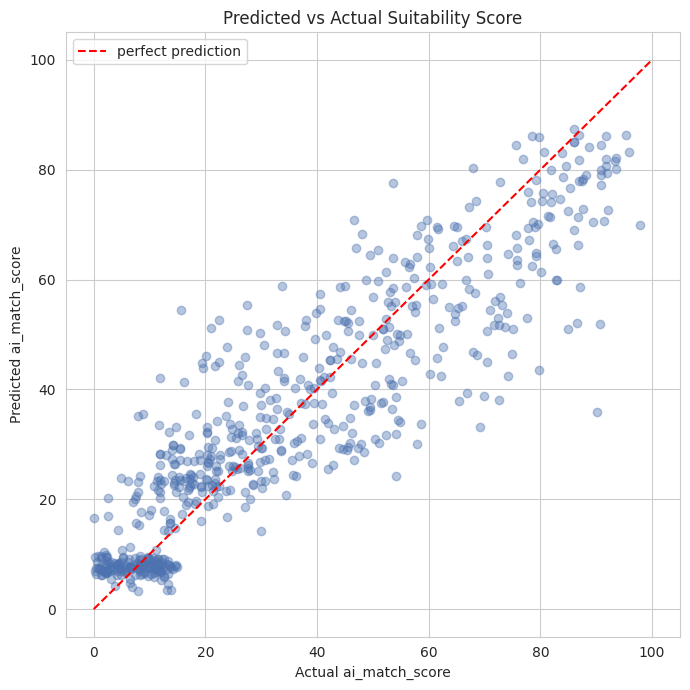

In [42]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_suit, y_pred_suit, alpha=0.4, color='#4C72B0')
plt.plot([0, 100], [0, 100], 'r--', label='perfect prediction')
plt.xlabel('Actual ai_match_score')
plt.ylabel('Predicted ai_match_score')
plt.title('Predicted vs Actual Suitability Score')
plt.legend()
plt.tight_layout()
plt.savefig('chart_predicted_vs_actual.png', dpi=150)
plt.show()

## Feature importance

text_similarity (plain TF-IDF) ended up the dominant feature - the fancier
embedding_similarity added only marginal value on top of it, which says
resume-JD fit in this dataset is driven more by shared vocabulary than by
semantic paraphrasing.

In [43]:
importances = pd.Series(suitability_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances

,0
text_similarity,0.470882
fuzzy_match_score,0.298075
skill_string_match_score,0.112895
embedding_similarity,0.059256
skill_overlap_ratio,0.020595
skill_overlap_count,0.018528
skill_text_similarity,0.010654
length_ratio,0.009116


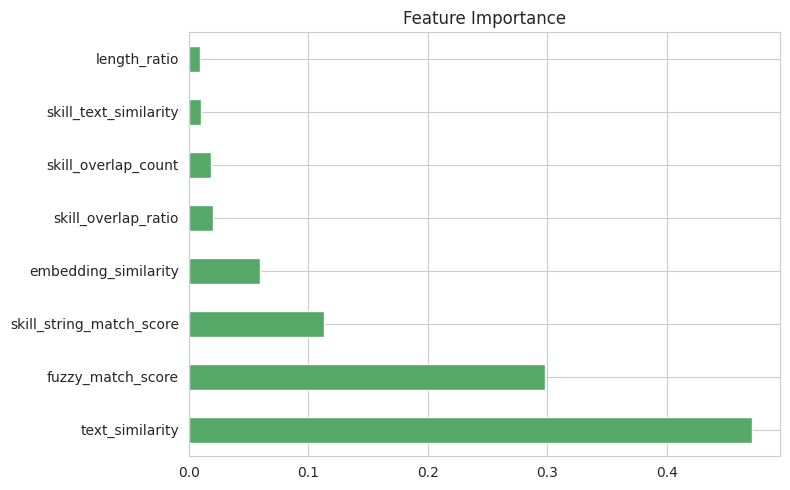

In [44]:
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#55A868')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('chart_feature_importance.png', dpi=150)
plt.show()

## Error by category

Negative pairs specifically helped HR (20.7 -> ~11.5 avg error) and IT
(18.5 -> ~14.1) - these had the widest range of real-world suitability before
and had nothing to contrast against.

In [45]:
results_df = X_test_suit.copy()
results_df['actual'] = y_test_suit.values
results_df['predicted'] = y_pred_suit
results_df['category'] = df_full.loc[X_test_suit.index, 'category'].values
results_df['abs_error'] = (results_df['actual'] - results_df['predicted']).abs()

category_error_df = results_df.groupby('category')['abs_error'].mean().sort_values(ascending=False)
category_error_df

,abs_error
category,
INFORMATION-TECHNOLOGY,13.164104
BPO,12.765773
HR,10.732273
DESIGNER,10.142648
SALES,9.938593
PUBLIC-RELATIONS,9.879269
FITNESS,9.845476
CONSTRUCTION,9.839283
BUSINESS-DEVELOPMENT,9.827708


# Part 4 - Download Everything

Saving every table and chart from the notebook, plus the trained models, in
one place so nothing has to be tracked down individually.

In [46]:
# tables -> csv
cat_counts.to_frame('count').to_csv('table_resumes_per_category.csv')
avg_len_by_cat.to_frame('avg_word_count').to_csv('table_avg_length_by_category.csv')
classification_report_df.to_csv('table_classification_report.csv')
mistakes_df.to_csv('table_confusion_mistakes.csv', index=False)
model_comparison_df.to_csv('table_model_comparison.csv')
importances.to_frame('importance').to_csv('table_feature_importance.csv')
category_error_df.to_frame('avg_abs_error').to_csv('table_category_error.csv')

print("Tables saved:")
print("- table_resumes_per_category.csv")
print("- table_avg_length_by_category.csv")
print("- table_classification_report.csv")
print("- table_confusion_mistakes.csv")
print("- table_model_comparison.csv")
print("- table_feature_importance.csv")
print("- table_category_error.csv")

Tables saved:
- table_resumes_per_category.csv
- table_avg_length_by_category.csv
- table_classification_report.csv
- table_confusion_mistakes.csv
- table_model_comparison.csv
- table_feature_importance.csv
- table_category_error.csv


In [47]:
# models + vectorizers
df.to_csv('Resume_clean.csv', index=False)

with open('category_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('suitability_model.pkl', 'wb') as f:
    pickle.dump(suitability_model, f)
with open('suitability_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer_s2, f)
with open('skill_vectorizer.pkl', 'wb') as f:
    pickle.dump(skill_vectorizer, f)

print("Models saved:")
print("- category_classifier.pkl + tfidf_vectorizer.pkl")
print("- suitability_model.pkl + suitability_vectorizer.pkl + skill_vectorizer.pkl")

Models saved:
- category_classifier.pkl + tfidf_vectorizer.pkl
- suitability_model.pkl + suitability_vectorizer.pkl + skill_vectorizer.pkl


In [49]:
from google.colab import files

# download everything in one go
files_to_download = [
    # charts
    'chart_resumes_per_category.png',
    'chart_resume_length.png',
    'chart_confusion_matrix.png',
    'chart_predicted_vs_actual.png',
    'chart_feature_importance.png',
    # tables
    'table_resumes_per_category.csv',
    'table_avg_length_by_category.csv',
    'table_classification_report.csv',
    'table_confusion_mistakes.csv',
    'table_model_comparison.csv',
    'table_feature_importance.csv',
    'table_category_error.csv',
    # data + models
    'Resume_clean.csv',
    'category_classifier.pkl',
    'tfidf_vectorizer.pkl',
    'suitability_model.pkl',
    'suitability_vectorizer.pkl',
    'skill_vectorizer.pkl',
]

for fname in files_to_download:
    files.download(fname)

print(f"Downloaded {len(files_to_download)} files.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 18 files.


## A quick honesty note

skill_string_match_stub and fuzzy_match_stub below are my own approximations, not the original dataset's real scoring formula — the author's RecAI pipeline that produced skill_string_match_score and fuzzy_match_score isn't public. These stand-ins follow the same idea (verbatim skill matching / fuzzy text overlap) but aren't guaranteed to match the original method exactly.

## Score a New Resume Against a Job Description

In [53]:
import re
from difflib import SequenceMatcher

# grab the skill vocabulary once, outside the function, so it's not
# rebuilt on every single call
SKILL_VOCAB = skill_vectorizer.get_feature_names_out()


def extract_skills(text, vocab=SKILL_VOCAB):
    """
    Pulls skills out of raw text by checking which terms from the skill
    vocabulary (the one skill_vectorizer was fit on during training) show up
    in it, matched as whole words/phrases only - not as substrings inside
    unrelated words. Not a fancy NER model, just word-boundary matching
    against real skills seen in the training data, which is honest about
    what it is and good enough for a demo scoring function.
    """
    text_lower = text.lower()
    found = []
    for skill in vocab:
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found.append(skill)
    return found


def skill_string_match_stub(resume_text, job_skills):
    """
    Stand-in for skill_string_match_score. The original dataset's version
    came from the author's own RecAI pipeline, which isn't public - this is
    a simple honest substitute: % of the job's required skills found
    verbatim (whole word/phrase) in the resume text.
    """
    if not job_skills:
        return 0.0
    text_lower = resume_text.lower()
    matches = sum(
        1 for s in job_skills
        if re.search(r'\b' + re.escape(s) + r'\b', text_lower)
    )
    return 100 * matches / len(job_skills)


def fuzzy_match_stub(resume_skills, job_skills):
    """
    Stand-in for fuzzy_match_score. Uses difflib's sequence matcher on the
    joined skill strings instead of the original's fuzzy-token method -
    same idea (tolerate near-matches like "ML" vs "Machine Learning"),
    simpler implementation.
    """
    resume_str = ' '.join(resume_skills)
    job_str = ' '.join(job_skills)
    if not resume_str or not job_str:
        return 0.0
    return SequenceMatcher(None, resume_str, job_str).ratio() * 100


def score_resume_against_job(resume_text, job_text):
    """
    Full Stage 1 + Stage 2 pipeline on a brand new resume/JD pair:
    predicts the resume's category, then scores how well it fits the
    specific job description using the trained suitability model.
    """
    # Step 1: predict category (Stage 1)
    category = clf.predict(vectorizer.transform([resume_text]))[0]

    # Step 2: compute all 8 features, same way as training
    resume_skills = extract_skills(resume_text)
    job_skills = extract_skills(job_text)

    resume_set, job_set = set(resume_skills), set(job_skills)
    skill_overlap_ratio_val = len(resume_set & job_set) / len(job_set) if job_set else 0.0
    skill_overlap_count_val = len(resume_set & job_set)

    resume_word_count = len(resume_text.split())
    job_word_count = len(job_text.split())
    length_ratio_val = min(resume_word_count, job_word_count) / max(resume_word_count, job_word_count, 1)

    text_sim = cosine_similarity(
        vectorizer_s2.transform([resume_text]),
        vectorizer_s2.transform([job_text])
    )[0][0]

    skill_text_sim = cosine_similarity(
        skill_vectorizer.transform([' '.join(resume_skills)]),
        skill_vectorizer.transform([' '.join(job_skills)])
    )[0][0]

    resume_emb = embed_model.encode([resume_text])
    job_emb = embed_model.encode([job_text])
    embedding_sim = cosine_similarity(resume_emb, job_emb)[0][0]

    skill_string_score = skill_string_match_stub(resume_text, job_skills)
    fuzzy_score = fuzzy_match_stub(resume_skills, job_skills)

    # Step 3: predict suitability - wrapped in a DataFrame with the same
    # column names used during training, avoids the sklearn feature-name
    # mismatch warning
    features_df = pd.DataFrame([[
        skill_overlap_ratio_val, skill_overlap_count_val, length_ratio_val,
        text_sim, skill_text_sim, embedding_sim,
        skill_string_score, fuzzy_score
    ]], columns=feature_cols)

    score = suitability_model.predict(features_df)[0]

    return {
        'predicted_category': category,
        'suitability_score': round(score, 1),
        'matched_skills': sorted(resume_set & job_set)
    }

In [54]:
score_resume_against_job(X_test_cat.iloc[0], "Seeking an experienced HR professional with talent acquisition and employee relations background")

{'predicted_category': 'FITNESS',
 'suitability_score': np.float64(39.9),
 'matched_skills': ['background',
  'employee',
  'hr',
  'professional',
  'relations']}